In [43]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

In [44]:
# read the processed data
data = pd.read_csv("../data/processed/processed_data_low.csv")
data.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,Month,MarketTemp,date,NewConSales,ZHVI_Tier,ZORDI_Condo,ZORDI_MFR,ZORDI_SFR,ZORDI_All,DaysToClose
0,394297,677,"Aberdeen, SD",msa,SD,2020-06-30,59.0,2020-06-01,NaN,171702.082197,NaN,NaN,NaN,NaN,NaN
1,394298,473,"Aberdeen, WA",msa,WA,2020-06-30,97.0,2020-06-01,NaN,235972.537055,NaN,NaN,NaN,NaN,NaN
2,394299,251,"Abilene, TX",msa,TX,2020-06-30,59.0,2020-06-01,34.0,152751.072291,NaN,71.0,104.0,94.0,NaN
3,394300,720,"Ada, OK",msa,OK,2020-06-30,73.0,2020-06-01,NaN,125912.908639,NaN,NaN,NaN,NaN,NaN
4,394302,393,"Adrian, MI",msa,MI,2020-06-30,108.0,2020-06-01,NaN,164669.930398,NaN,NaN,NaN,NaN,NaN


In [45]:
sd = data[data["RegionName"] == "Adrian, MI"]
sd

,RegionID,SizeRank,RegionName,RegionType,StateName,Month,MarketTemp,date,NewConSales,ZHVI_Tier,ZORDI_Condo,ZORDI_MFR,ZORDI_SFR,ZORDI_All,DaysToClose
4,394302,393,"Adrian, MI",msa,MI,2020-06-30,108.0,2020-06-01,NaN,164669.930398,NaN,NaN,NaN,NaN,NaN
908,394302,393,"Adrian, MI",msa,MI,2020-07-31,115.0,2020-07-01,NaN,167655.095769,NaN,NaN,NaN,NaN,NaN
1812,394302,393,"Adrian, MI",msa,MI,2020-08-31,109.0,2020-08-01,NaN,170685.682600,NaN,NaN,NaN,NaN,NaN
2715,394302,393,"Adrian, MI",msa,MI,2020-09-30,103.0,2020-09-01,NaN,173570.235649,NaN,NaN,NaN,NaN,NaN
3618,394302,393,"Adrian, MI",msa,MI,2020-10-31,96.0,2020-10-01,NaN,174922.979947,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58175,394302,393,"Adrian, MI",msa,MI,2025-09-30,33.0,2025-09-01,NaN,231288.842267,NaN,22.0,51.0,29.0,NaN
59107,394302,393,"Adrian, MI",msa,MI,2025-10-31,29.0,2025-10-01,NaN,231208.009400,6.0,19.0,48.0,27.0,NaN
60039,394302,393,"Adrian, MI",msa,MI,2025-11-30,31.0,2025-11-01,NaN,231177.552363,29.0,14.0,37.0,25.0,NaN
60971,394302,393,"Adrian, MI",msa,MI,2025-12-31,36.0,2025-12-01,NaN,230486.468867,32.0,11.0,40.0,27.0,NaN


In [46]:
target = pd.Series(sd["MarketTemp"])

print(target)

train = target[:-16]
test = target[-16:]

4        108.0
908      115.0
1812     109.0
2715     103.0
3618      96.0
         ...  
58175     33.0
59107     29.0
60039     31.0
60971     36.0
61902     46.0
Name: MarketTemp, Length: 68, dtype: float64


In [47]:
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

/home/ramos/miniconda3/envs/capstone_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/ramos/miniconda3/envs/capstone_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/ramos/miniconda3/envs/capstone_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Forecast:
52    35.887043
53    33.580970
54    32.540872
55    32.071761
56    31.860180
57    31.764752
58    31.721711
59    31.702299
60    31.693543
61    31.689594
62    31.687813
63    31.687010
64    31.686648
65    31.686484
66    31.686410
67    31.686377
Name: predicted_mean, dtype: float64
RMSE: 14.4564


/home/ramos/miniconda3/envs/capstone_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/ramos/miniconda3/envs/capstone_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


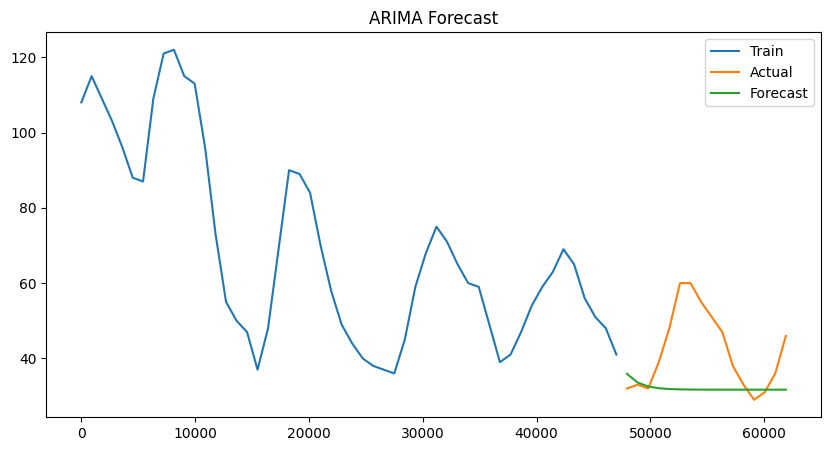

In [48]:
forecast = model_fit.forecast(steps=len(test))

# Evaluate
rmse = np.sqrt(mean_squared_error(test, forecast))
print("Forecast:")
print(forecast)
print(f"RMSE: {rmse:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

Arima seems to not be a good model, lets check mean and variance stability

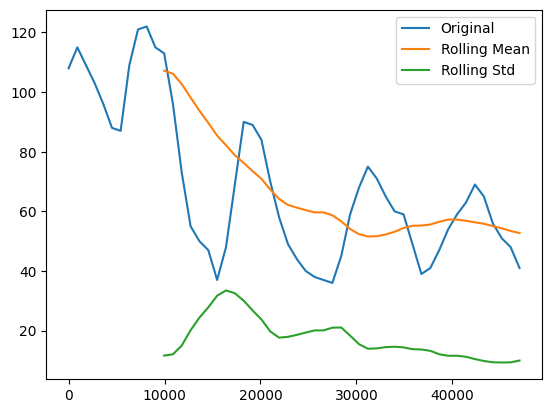

In [49]:
rolling_mean = train.rolling(window=12).mean()
rolling_std = train.rolling(window=12).std()

plt.plot(train, label="Original")
plt.plot(rolling_mean, label="Rolling Mean")
plt.plot(rolling_std, label="Rolling Std")
plt.legend()
plt.show()

In [50]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.799447603383786
p-value: 5.4518420825093314e-05


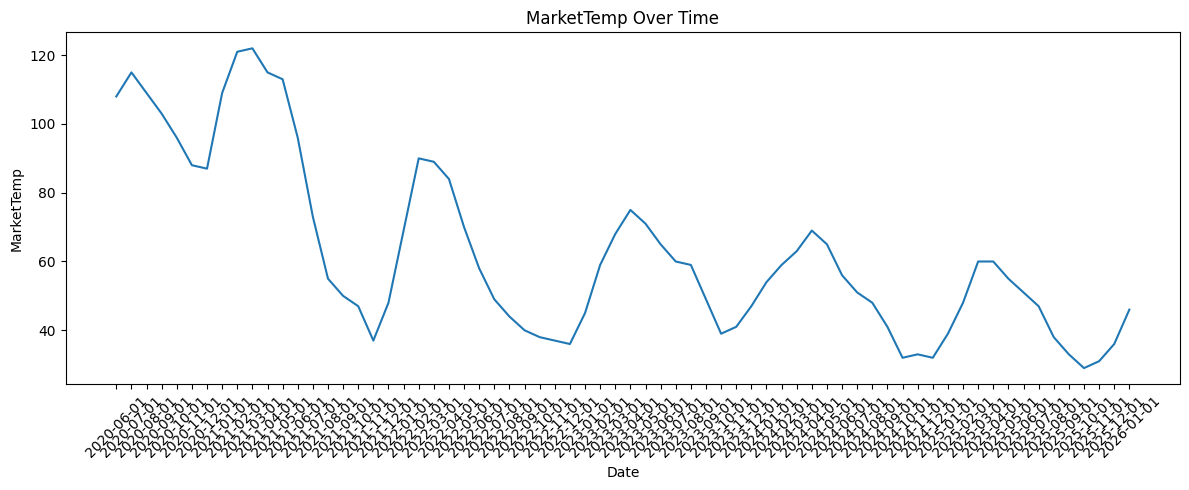

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(sd["date"], sd["MarketTemp"])
plt.title("MarketTemp Over Time")
plt.xlabel("Date")
plt.ylabel("MarketTemp")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

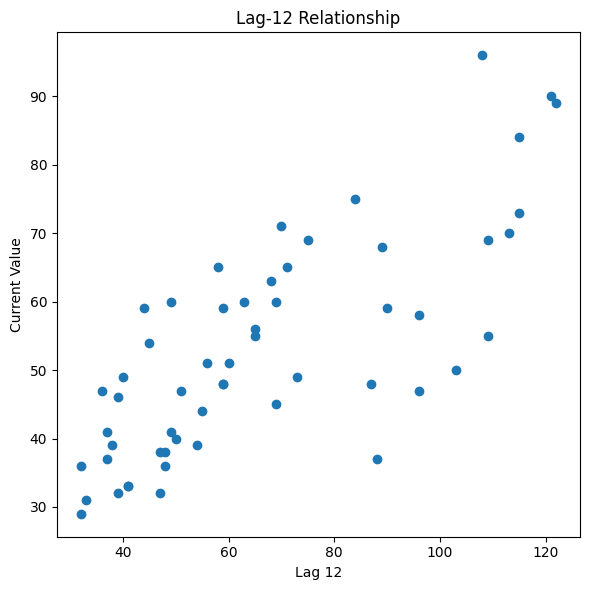

In [52]:
sd = sd.sort_values("date").copy()
sd["lag_12"] = sd["MarketTemp"].shift(12)

plt.figure(figsize=(6, 6))
plt.scatter(sd["lag_12"], sd["MarketTemp"])
plt.xlabel("Lag 12")
plt.ylabel("Current Value")
plt.title("Lag-12 Relationship")
plt.tight_layout()
plt.show()

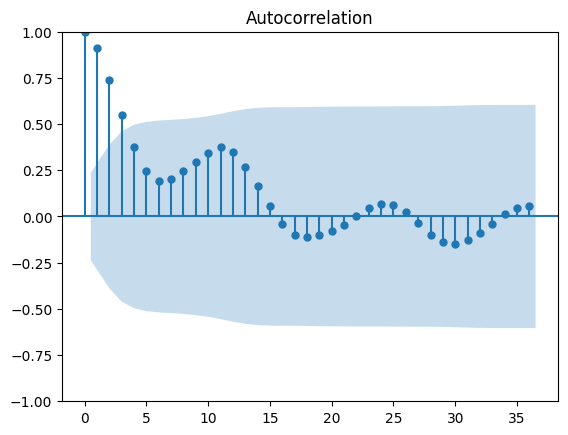

In [53]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

y = sd["MarketTemp"].dropna()

plot_acf(y, lags=36)
plt.show()

Due to the present of seasonality, lets move to SARIMA

/home/ramos/miniconda3/envs/capstone_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/ramos/miniconda3/envs/capstone_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/ramos/miniconda3/envs/capstone_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/ramos/miniconda3/envs/capstone_env/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: Futur

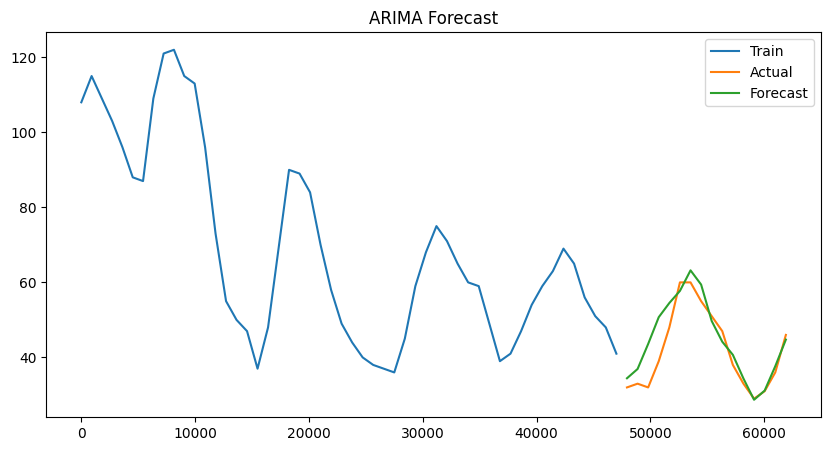

In [54]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test))

plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

In [58]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_forecast(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }

metrics = evaluate_forecast(test, forecast)
print(metrics)

{'RMSE': np.float64(4.960119188898249), 'MAE': 3.60059405515488, 'MAPE': np.float64(9.069651928183376)}
